# Preprocessing Pipeline — BDC 2026 Identifikasi Jenis Sampah

**Pipeline lengkap (jalankan secara berurutan):**

| Cell | Langkah | Keterangan |
|------|---------|------------|
| 1 | Setup & Import | Library dan konfigurasi path |
| 2 | Konfigurasi | Path, target, seed |
| 3 | **[CLEANUP] Hapus Duplikat MD5** | Hapus file yang byte-identik |
| 4 | **[CLEANUP] Convert Non-RGB -> RGB** | Convert mode Palette P ke RGB in-place |
| 5 | Load EDA Scores | Baca skor_akhir untuk strategi crop |
| 6 | Fungsi Augmentasi v2 | Cara 2 kontinu, 12 jenis augmentasi agresif |
| 7 | Pipeline Augmentasi Electronic | Generate ~4,039 gambar baru |
| 8 | Build Manifest CSV | Daftar semua processed data + label |
| 9 | Verifikasi & Visualisasi | Distribusi kelas + grid contoh |

---
**Hasil EDA yang menjadi dasar keputusan:**
- Electronic hanya 14.9% dari total -> augmentasi ke 26.1%
- 281 gambar non-RGB (mode Palette P) -> wajib diconvert
- 62 pasang duplikat MD5 identik -> hapus satu per pasang
- Crop scale berbasis skor_akhir: skor=0 -> scale(0.75,0.95) | skor=1 -> scale(0.30,0.65)

In [1]:
# CELL 1 - Setup & Import
import os, math, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageEnhance, ImageFilter, ImageOps, ImageDraw

try:
    import ipywidgets
    from tqdm.notebook import tqdm
    print('tqdm mode: notebook')
except ImportError:
    from tqdm import tqdm
    print('tqdm mode: text (ipywidgets tidak tersedia)')

import warnings
warnings.filterwarnings('ignore')
print('Import selesai')

tqdm mode: text (ipywidgets tidak tersedia)
Import selesai


In [2]:
# CELL 2 - Konfigurasi
ROOT           = Path(r"d:\Bagas\Satria_Data_BDC\BDC 2026")
TRAIN_DIR      = ROOT / "train"
EDA_DIR        = ROOT / "EDA"
PREPROC_DIR    = ROOT / "Preprocessing_Data"

ELECTRONIC_DIR = TRAIN_DIR / "1_Electronic"
OUTPUT_DIR     = PREPROC_DIR / "augmented_electronic"
TRAIN_MANIFEST_PATH = PREPROC_DIR / "train_manifest.csv"
VAL_MANIFEST_PATH   = PREPROC_DIR / "val_manifest.csv"

CSV_FULL_FRAME = EDA_DIR / "eda_deteksi_full_frame.csv"
CSV_DUPLIKAT   = EDA_DIR / "eda_duplikat_identik.csv"
CSV_PROPERTI   = EDA_DIR / "eda_properti_teknis.csv"

CLASS_MAP = {
    "0_Recyclable": ("Recyclable", 0),
    "1_Electronic": ("Electronic", 1),
    "2_Organic":    ("Organic",    2),
}

TARGET_TOTAL   = 8_000
IMG_SIZE       = 224
SEED           = 42
OVERWRITE_AUG  = True  # True = hapus augmented lama dan regenerate

random.seed(SEED)
np.random.seed(SEED)

print('Konfigurasi:')
print('  ROOT         :', ROOT)
print('  TARGET_TOTAL :', TARGET_TOTAL)
print('  IMG_SIZE     :', IMG_SIZE)


Konfigurasi:
  ROOT         : d:\Bagas\Satria_Data_BDC\BDC 2026
  TARGET_TOTAL : 8000
  IMG_SIZE     : 224


In [3]:
# ============================================================
# CELL 3 - [CLEANUP] Hapus Duplikat Identik (MD5)
# ============================================================
# Dari EDA: ditemukan 62 pasang gambar dengan MD5 hash identik
# (byte-level identik) -> satu per pasang disimpan, sisanya dihapus
# Distribusi: Electronic=30, Organic=22, Recyclable=9
# ============================================================

print('STEP 1: Hapus Duplikat Identik (MD5)')
print('=' * 50)

df_dup = pd.read_csv(CSV_DUPLIKAT)
deleted = []
skipped = []

for md5, group in df_dup.groupby('md5_hash'):
    files_in_group = group['nama_file'].tolist()
    labels         = group['label'].tolist()

    for label in set(labels):
        folder = [k for k, v in CLASS_MAP.items() if v[0] == label][0]
        class_dir = TRAIN_DIR / folder
        same_label = sorted([f for f, l in zip(files_in_group, labels) if l == label])
        to_del = same_label[1:]  # simpan yang pertama, hapus sisanya

        for fname in to_del:
            fpath = class_dir / fname
            if fpath.exists():
                os.remove(fpath)
                deleted.append(label + '/' + fname)
                print('  HAPUS: ' + label + '/' + fname)
            else:
                skipped.append(fname)  # sudah dihapus sebelumnya

print()
print('Dihapus         :', len(deleted), 'file')
print('Skip (tdk ada)  :', len(skipped), 'file')
if skipped:
    print('(File skip sudah dihapus di run sebelumnya)')

STEP 1: Hapus Duplikat Identik (MD5)

Dihapus         : 0 file
Skip (tdk ada)  : 61 file
(File skip sudah dihapus di run sebelumnya)


In [4]:
# ============================================================
# CELL 4 - [CLEANUP] Convert Non-RGB (Mode P) -> RGB
# ============================================================
# Dari EDA: 214 gambar Recyclable + 67 Organic dalam mode Palette (P)
# Mode P tidak bisa langsung dipakai model -> wajib convert ke RGB
# Disimpan in-place sebagai .jpg (quality=95)
# ============================================================

print('STEP 2: Convert Non-RGB (mode Palette P) -> RGB')
print('=' * 50)

df_prop = pd.read_csv(CSV_PROPERTI)
non_rgb = df_prop[df_prop['mode_warna'] != 'RGB']

converted = []
skip_conv = []
err_conv  = []

for _, row in non_rgb.iterrows():
    folder    = [k for k, v in CLASS_MAP.items() if v[0] == row['label']][0]
    class_dir = TRAIN_DIR / folder
    stem      = Path(row['nama_file']).stem

    fpath = None
    for ext in ['.jpg', '.jpeg', '.png']:
        candidate = class_dir / (stem + ext)
        if candidate.exists():
            fpath = candidate
            break

    if fpath is None:
        skip_conv.append(row['nama_file'])
        continue

    try:
        img = Image.open(fpath)
        if img.mode == 'RGB':
            skip_conv.append(row['nama_file'])
            continue
        img_rgb   = img.convert('RGB')
        save_path = fpath.with_suffix('.jpg')
        img_rgb.save(save_path, 'JPEG', quality=95)
        if fpath != save_path and fpath.exists():
            os.remove(fpath)
        converted.append(save_path.name)
        print('  CONVERT: ' + row['label'] + '/' + save_path.name + '  (' + img.mode + ' -> RGB)')
    except Exception as e:
        err_conv.append(row['nama_file'] + ' | ' + str(e))

print()
print('Diconvert                  :', len(converted), 'file')
print('Skip (sudah RGB/tdk ada)   :', len(skip_conv), 'file')
if err_conv:
    print('Error                      :', len(err_conv), 'file')
    for e in err_conv[:5]:
        print(' ', e)

# Verifikasi jumlah file setelah cleanup
print()
print('Jumlah file setelah cleanup:')
for folder, (label, _) in CLASS_MAP.items():
    files = [f for f in (TRAIN_DIR / folder).glob('*')
             if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    print('  ' + label + ': ' + str(len(files)) + ' file')

STEP 2: Convert Non-RGB (mode Palette P) -> RGB

Diconvert                  : 0 file
Skip (sudah RGB/tdk ada)   : 312 file

Jumlah file setelah cleanup:
  Recyclable: 9990 file
  Electronic: 3930 file
  Organic: 12545 file


In [5]:
# CELL 5 - Load EDA Scores
df_eda = pd.read_csv(CSV_FULL_FRAME)
df_elec = df_eda[df_eda['label'] == 'Electronic'][['nama_file', 'skor_akhir']].dropna()
score_map = dict(zip(df_elec['nama_file'], df_elec['skor_akhir']))

existing_files = [f for f in ELECTRONIC_DIR.glob('*')
                  if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]

FALLBACK_SCORE = df_elec['skor_akhir'].median()
file_scores = [(f, score_map.get(f.name, FALLBACK_SCORE)) for f in existing_files]

scores_all = [s for _, s in file_scores]
n_full = sum(1 for s in scores_all if s >= 0.65)
n_mid  = sum(1 for s in scores_all if 0.35 <= s < 0.65)
n_bg   = sum(1 for s in scores_all if s < 0.35)

print('Load EDA Scores selesai')
print('  Total Electronic di disk  :', len(existing_files))
print('  Match EDA score           :', sum(1 for f, _ in file_scores if f.name in score_map))
print('  full_frame (>=0.65)       :', n_full, '(' + str(round(100*n_full/len(scores_all),1)) + '%)')
print('  perlu_cek_manual (0.35-0.65):', n_mid, '(' + str(round(100*n_mid/len(scores_all),1)) + '%)')
print('  background_terpisah (<0.35):', n_bg, '(' + str(round(100*n_bg/len(scores_all),1)) + '%)')

Load EDA Scores selesai
  Total Electronic di disk  : 3930
  Match EDA score           : 3902
  full_frame (>=0.65)       : 1879 (47.8%)
  perlu_cek_manual (0.35-0.65): 1251 (31.8%)
  background_terpisah (<0.35): 800 (20.4%)


In [6]:
# CELL 6 - Fungsi Augmentasi AGRESIF v2

def lerp(a, b, t):
    return a + (b - a) * float(np.clip(t, 0.0, 1.0))

def get_crop_scale_v2(skor):
    scale_min = lerp(0.75, 0.30, skor)
    scale_max = lerp(0.95, 0.65, skor)
    return (round(scale_min, 4), round(scale_max, 4))

def random_resized_crop(img, scale, ratio=(0.67, 1.50)):
    w, h = img.size
    area = w * h
    for _ in range(12):
        ta = random.uniform(scale[0], scale[1]) * area
        ar = random.uniform(ratio[0], ratio[1])
        nw = int(round(math.sqrt(ta * ar)))
        nh = int(round(math.sqrt(ta / ar)))
        if 0 < nw <= w and 0 < nh <= h:
            x = random.randint(0, w - nw)
            y = random.randint(0, h - nh)
            return img.crop((x, y, x+nw, y+nh))
    side = min(w, h)
    return img.crop(((w-side)//2, (h-side)//2, (w+side)//2, (h+side)//2))

def _find_perspective_coeffs(pa, pb):
    matrix = []
    for p1, p2 in zip(pa, pb):
        matrix.append([p1[0], p1[1], 1, 0, 0, 0, -p2[0]*p1[0], -p2[0]*p1[1]])
        matrix.append([0, 0, 0, p1[0], p1[1], 1, -p2[1]*p1[0], -p2[1]*p1[1]])
    A = np.matrix(matrix, dtype=np.float64)
    B = np.array(pb).reshape(8)
    return np.linalg.solve(A, B).flatten().tolist()

def perspective_warp(img, magnitude=0.20):
    w, h = img.size
    mx = int(magnitude * w)
    my = int(magnitude * h)
    rw = lambda: random.randint(-mx, mx)
    rh = lambda: random.randint(-my, my)
    src = [(0,0),(w,0),(w,h),(0,h)]
    dst = [(rw(),rh()),(w+rw(),rh()),(w+rw(),h+rh()),(rw(),h+rh())]
    try:
        return img.transform(img.size, Image.PERSPECTIVE,
                             _find_perspective_coeffs(src, dst), Image.BILINEAR)
    except Exception:
        return img

def random_cutout(img, n_holes=1, min_frac=0.08, max_frac=0.22):
    img = img.copy()
    draw = ImageDraw.Draw(img)
    w, h = img.size
    for _ in range(n_holes):
        cw = int(random.uniform(min_frac, max_frac) * w)
        ch = int(random.uniform(min_frac, max_frac) * h)
        x  = random.randint(0, w - cw)
        y  = random.randint(0, h - ch)
        draw.rectangle([x, y, x+cw, y+ch], fill=(115, 115, 115))
    return img

def add_gaussian_noise(img, std=0.05):
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.clip(arr + np.random.normal(0, std, arr.shape), 0, 1)
    return Image.fromarray((arr * 255).astype(np.uint8))

def augment_image_v2(img_path, skor, aug_idx=0):
    seed_val = (SEED + aug_idx * 1000 + hash(img_path.name) % 100000) % (2**31)
    random.seed(seed_val)
    np.random.seed(seed_val)

    img = Image.open(img_path).convert('RGB')
    img = random_resized_crop(img, scale=get_crop_scale_v2(skor))
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    if random.random() < 0.50: img = ImageOps.mirror(img)
    if random.random() < 0.25: img = ImageOps.flip(img)
    if random.random() < 0.40: img = perspective_warp(img, magnitude=random.uniform(0.12, 0.22))
    if random.random() < 0.50: img = img.rotate(random.uniform(-30, 30), resample=Image.BILINEAR, expand=False)
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.40, 1.60))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.45, 1.55))
    img = ImageEnhance.Color(img).enhance(random.uniform(0.40, 1.60))
    if random.random() < 0.12: img = ImageOps.grayscale(img).convert('RGB')
    if random.random() < 0.08:
        r, g, b = img.split()
        img = Image.merge('RGB', random.choice([(r,g,b),(g,r,b),(b,g,r),(r,b,g)]))
    rnd = random.random()
    if rnd < 0.20: img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 2.0)))
    elif rnd < 0.40: img = ImageEnhance.Sharpness(img).enhance(random.uniform(1.5, 3.0))
    if random.random() < 0.25: img = add_gaussian_noise(img, std=random.uniform(0.02, 0.06))
    if random.random() < 0.30: img = random_cutout(img, n_holes=random.choice([1, 2]))
    return img

print('Fungsi augmentasi v2 siap')
print('Sanity check crop scale:')
for s in [0.0, 0.35, 0.65, 1.0]:
    zona = 'full_frame' if s >= 0.65 else ('perlu_cek' if s >= 0.35 else 'background')
    smin, smax = get_crop_scale_v2(s)
    print('  skor=' + str(s) + ' [' + zona + '] -> scale(' + str(smin) + ', ' + str(smax) + ')')

Fungsi augmentasi v2 siap
Sanity check crop scale:
  skor=0.0 [background] -> scale(0.75, 0.95)
  skor=0.35 [perlu_cek] -> scale(0.5925, 0.845)
  skor=0.65 [full_frame] -> scale(0.4575, 0.755)
  skor=1.0 [full_frame] -> scale(0.3, 0.65)


In [7]:
# ============================================================
# CELL 6.5 - Stratified Train/Val Split (SEBELUM Augmentasi)
# ============================================================
print('Membuat Stratified Split (85% Train, 15% Val)...')
VAL_RATIO = 0.15
train_files_dict = {}
val_files_dict = {}

for folder, (label_name, label_id) in CLASS_MAP.items():
    class_dir = TRAIN_DIR / folder
    files = sorted([f for f in class_dir.glob('*') if f.suffix.lower() in ('.jpg', '.jpeg', '.png')])
    random.shuffle(files)
    n_val = int(len(files) * VAL_RATIO)
    val_files_dict[label_name] = files[:n_val]
    train_files_dict[label_name] = files[n_val:]
    print(f"{label_name.ljust(12)}: {len(train_files_dict[label_name])} train, {len(val_files_dict[label_name])} val")

# Update 'existing_files' and 'file_scores' for Electronic so that augmentation only happens on train data
train_elec_files = set(train_files_dict['Electronic'])
existing_files = [f for f in existing_files if f in train_elec_files]
file_scores = [(f, s) for f, s in file_scores if f in train_elec_files]
print(f"\nData Electronic Train yang akan diaugmentasi: {len(file_scores)}")


Membuat Stratified Split (85% Train, 15% Val)...
Recyclable  : 8492 train, 1498 val
Electronic  : 3341 train, 589 val
Organic     : 10664 train, 1881 val

Data Electronic Train yang akan diaugmentasi: 3341


In [8]:
# CELL 7 - Pipeline Augmentasi Electronic

if OVERWRITE_AUG and OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
    print('Folder augmented lama dihapus')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

existing_count = len(existing_files)
needed = max(0, TARGET_TOTAL - existing_count)
aug_per_img = math.ceil(needed / existing_count) if needed > 0 else 0

print('Electronic existing  :', existing_count)
print('Target total         :', TARGET_TOTAL)
print('Perlu dibuat         :', needed)

if needed <= 0:
    already = len(list(OUTPUT_DIR.glob('*.jpg')))
    print('Target sudah tercapai. File augmented di disk:', already)
else:
    generated = 0
    failed = 0

    with tqdm(total=needed, desc='Augmentasi Electronic v2', unit='img') as pbar:
        random.shuffle(file_scores)
        for aug_idx in range(aug_per_img):
            for img_path, skor in file_scores:
                if generated >= needed:
                    break
                try:
                    aug_img  = augment_image_v2(img_path, skor, aug_idx=aug_idx)
                    out_name = 'aug_' + str(generated).zfill(5) + '_' + img_path.stem + '.jpg'
                    aug_img.save(OUTPUT_DIR / out_name, 'JPEG', quality=90)
                    generated += 1
                    pbar.update(1)
                except Exception:
                    failed += 1
            if generated >= needed:
                break

    print('Generated :', generated)
    if failed: print('Gagal     :', failed)
    print('Total Electronic:', existing_count + generated)

Electronic existing  : 3341
Target total         : 8000
Perlu dibuat         : 4659


Augmentasi Electronic v2: 100%|██████████| 4659/4659 [01:35<00:00, 48.90img/s] 

Generated : 4659
Gagal     : 2
Total Electronic: 8000


In [9]:
# ============================================================
# CELL 8 - Build Train & Val Manifest CSV
# ============================================================
print('Membangun train_manifest.csv dan val_manifest.csv...')

train_rows = []
val_rows = []

for label_name, files in val_files_dict.items():
    label_id = [v[1] for k, v in CLASS_MAP.items() if v[0] == label_name][0]
    for f in files:
        val_rows.append({'file_path': str(f), 'label': label_name, 'label_id': label_id, 'source': 'original'})

for label_name, files in train_files_dict.items():
    label_id = [v[1] for k, v in CLASS_MAP.items() if v[0] == label_name][0]
    for f in files:
        train_rows.append({'file_path': str(f), 'label': label_name, 'label_id': label_id, 'source': 'original'})

for f in OUTPUT_DIR.glob('*.jpg'):
    train_rows.append({'file_path': str(f), 'label': 'Electronic', 'label_id': 1, 'source': 'augmented'})

df_val = pd.DataFrame(val_rows)
df_val = df_val[df_val['file_path'].apply(lambda p: Path(p).exists())]
df_val = df_val.sort_values(['label_id', 'file_path']).reset_index(drop=True)
df_val.to_csv(VAL_MANIFEST_PATH, index=False)

df_train = pd.DataFrame(train_rows)
df_train = df_train[df_train['file_path'].apply(lambda p: Path(p).exists())]
df_train = df_train.sort_values(['label_id', 'source', 'file_path']).reset_index(drop=True)
df_train.to_csv(TRAIN_MANIFEST_PATH, index=False)

print(f"\nTrain manifest tersimpan di {TRAIN_MANIFEST_PATH} ({len(df_train)} baris)")
print(f"Val manifest tersimpan di {VAL_MANIFEST_PATH} ({len(df_val)} baris)")


Membangun train_manifest.csv dan val_manifest.csv...

Train manifest tersimpan di d:\Bagas\Satria_Data_BDC\BDC 2026\Preprocessing_Data\train_manifest.csv (27154 baris)
Val manifest tersimpan di d:\Bagas\Satria_Data_BDC\BDC 2026\Preprocessing_Data\val_manifest.csv (3968 baris)


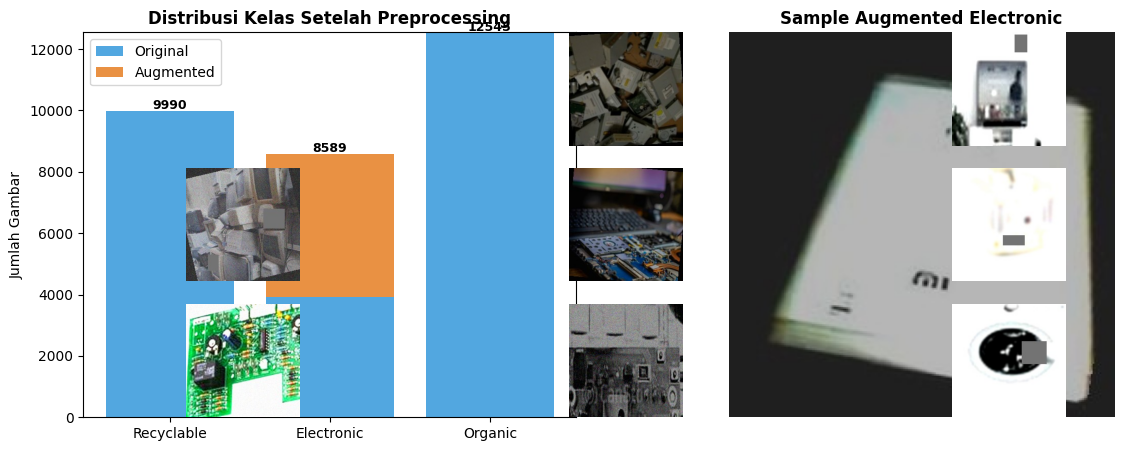

Plot disimpan: d:\Bagas\Satria_Data_BDC\BDC 2026\Preprocessing_Data\preprocessing_summary.png

Preprocessing selesai!
Gunakan train_manifest.csv dan val_manifest.csv sebagai input ke PyTorch Dataset


In [10]:
# CELL 9 - Verifikasi & Visualisasi
# Distribusi kelas bar chart
labels_list = ['Recyclable', 'Electronic', 'Organic']
counts_orig = [len([r for r in train_rows if r['label']==l and r['source']=='original']) + len([r for r in val_rows if r['label']==l and r['source']=='original']) for l in labels_list]
counts_aug  = [len([r for r in train_rows if r['label']==l and r['source']=='augmented']) for l in labels_list]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Bar chart distribusi
x = range(len(labels_list))
axes[0].bar(x, counts_orig, label='Original', color='#3498DB', alpha=0.85)
axes[0].bar(x, counts_aug,  label='Augmented', color='#E67E22', alpha=0.85,
            bottom=counts_orig)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels_list)
axes[0].set_title('Distribusi Kelas Setelah Preprocessing', fontweight='bold')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].legend()
for i, (o, a) in enumerate(zip(counts_orig, counts_aug)):
    axes[0].text(i, o + a + 50, str(o+a), ha='center', fontsize=9, fontweight='bold')
# Grid sample augmented
aug_files = list(OUTPUT_DIR.glob('*.jpg'))[:9]
if len(aug_files) >= 9:
    for idx, f in enumerate(aug_files[:9]):
        ax = axes[1] if idx == 0 else fig.add_subplot(3, 3, idx+1)
        try:
            img = Image.open(f)
            plt.imshow(img)
            plt.axis('off')
        except Exception:
            pass
    axes[1].set_title('Sample Augmented Electronic', fontweight='bold')
plt.tight_layout()
plt.savefig(PREPROC_DIR / 'preprocessing_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot disimpan:', PREPROC_DIR / 'preprocessing_summary.png')
print()
print('Preprocessing selesai!')
print('Gunakan train_manifest.csv dan val_manifest.csv sebagai input ke PyTorch Dataset')
